In [1]:
import os
from matplotlib import pyplot as plt
import pickle
from deer.utils.plots import plot_steps, get_plot_data, draw_trace_frequency_bars

In [91]:
path = '../traces/python_project3/'
traces_files = list(filter(lambda s: s.endswith(".trace"), os.listdir(path)))
traces_files = [os.path.join(path, file) for file in traces_files]
print(f"Se encontraron {len(traces_files)}")

data = get_plot_data(traces_files, threshold=1)

Se encontraron 100


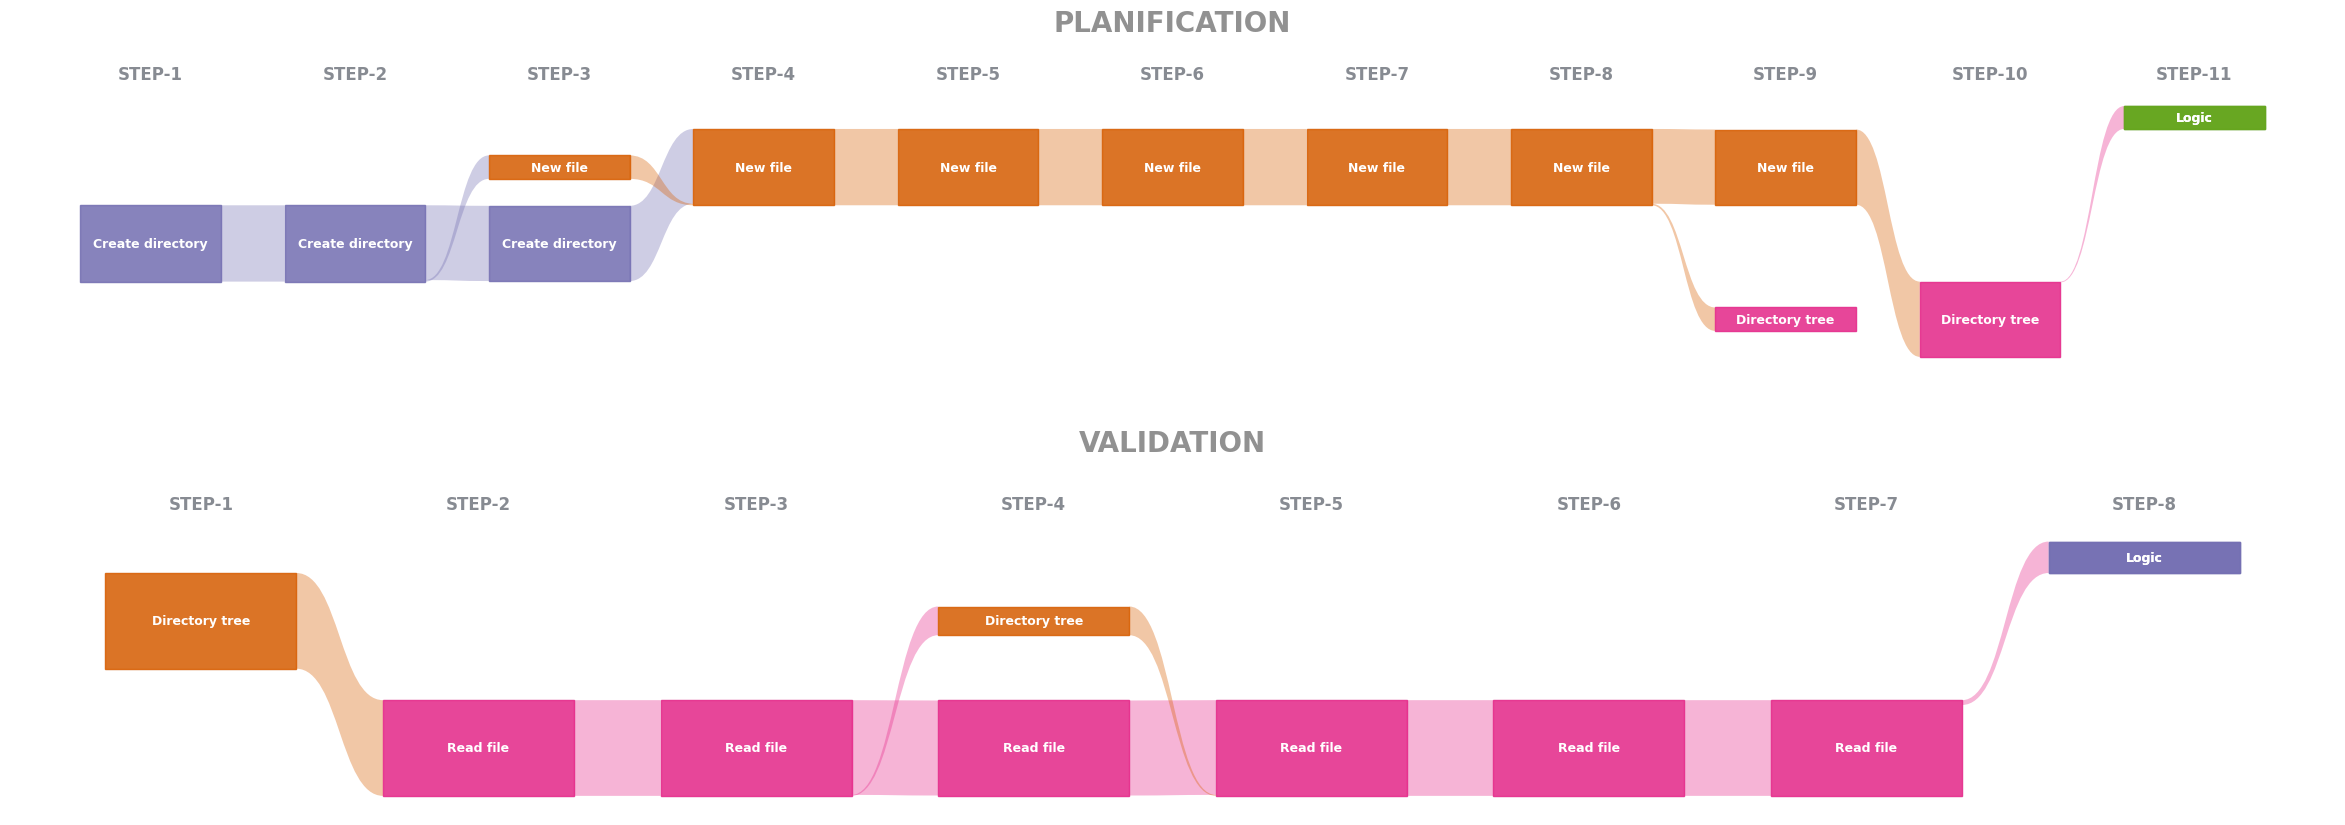

In [92]:
fig = plt.figure(figsize=(30, 10))
plot_steps(fig, *data, color_map_name='Dark2', font_color='#ffffff')
plt.show()

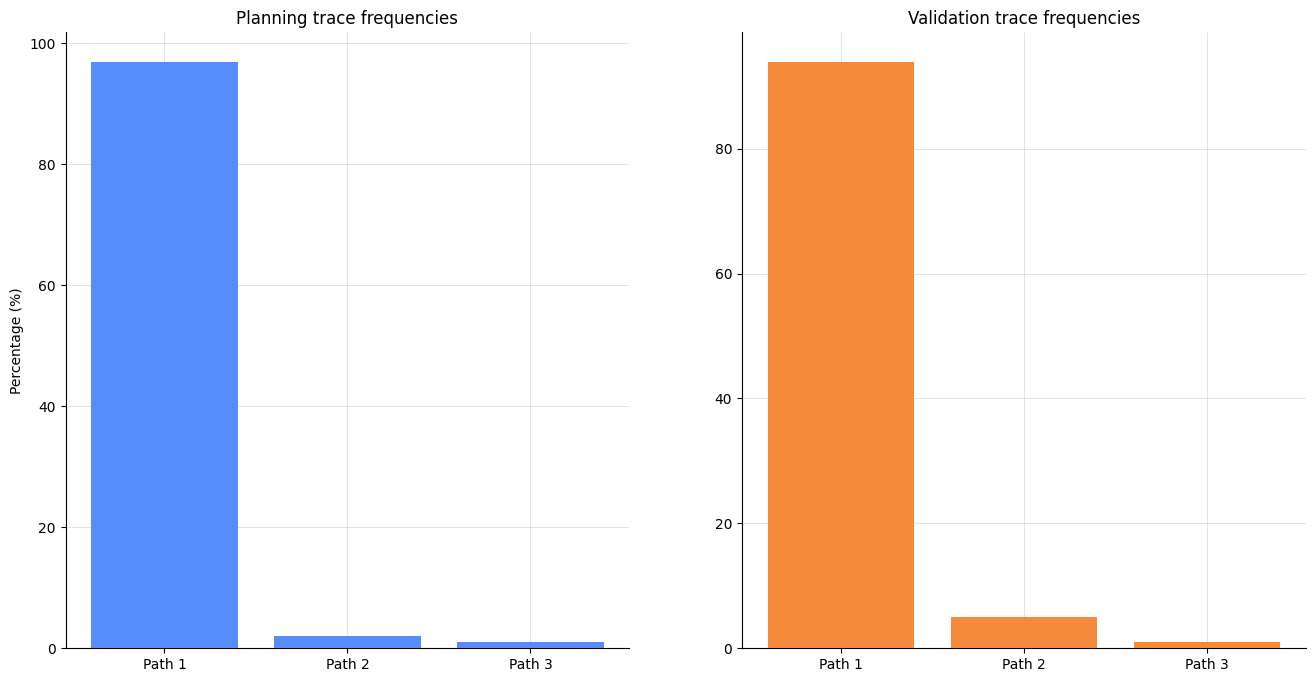

In [93]:
fig = plt.figure(figsize=(16, 8))
draw_trace_frequency_bars(fig, data)
plt.show()

In [94]:
trace = {
    'attempts': [],
    'solution': [],
    'verification': [],
}

c = 0
for file in traces_files:
    with open(file, 'rb') as f:
        d = pickle.load(f)
        if not d['trace']:
            print(file)
            continue
        c += 1
        tr = d['trace'][0]['execution_summary']


    print(f"Track{c}: {file}")

    solutions = 0
    verifications = 0
    for att in tr:
        solutions += len([s for s in tr[att].keys() if s.startswith('Solution')])
        verifications += len([s for s in tr[att].keys() if s.startswith('Verification')])

    trace['attempts'].append(len(tr))
    trace['solution'].append(solutions)
    trace['verification'].append(verifications)

Track1: ../traces/python_project3/gemma4:31b-cloud-1779762312.308063.trace
Track2: ../traces/python_project3/gemma4:31b-cloud-1779759447.33606.trace
Track3: ../traces/python_project3/gemma4:31b-cloud-1779759597.591236.trace
Track4: ../traces/python_project3/gemma4:31b-cloud-1779759341.652661.trace
Track5: ../traces/python_project3/gemma4:31b-cloud-1779763136.931106.trace
Track6: ../traces/python_project3/gemma4:31b-cloud-1779758448.735462.trace
Track7: ../traces/python_project3/gemma4:31b-cloud-1779762335.272881.trace
Track8: ../traces/python_project3/gemma4:31b-cloud-1779763156.057259.trace
Track9: ../traces/python_project3/gemma4:31b-cloud-1779762726.709286.trace
Track10: ../traces/python_project3/gemma4:31b-cloud-1779759633.625797.trace
Track11: ../traces/python_project3/gemma4:31b-cloud-1779758370.035821.trace
Track12: ../traces/python_project3/gemma4:31b-cloud-1779759424.299986.trace
Track13: ../traces/python_project3/gemma4:31b-cloud-1779761211.140945.trace
Track14: ../traces/pyt

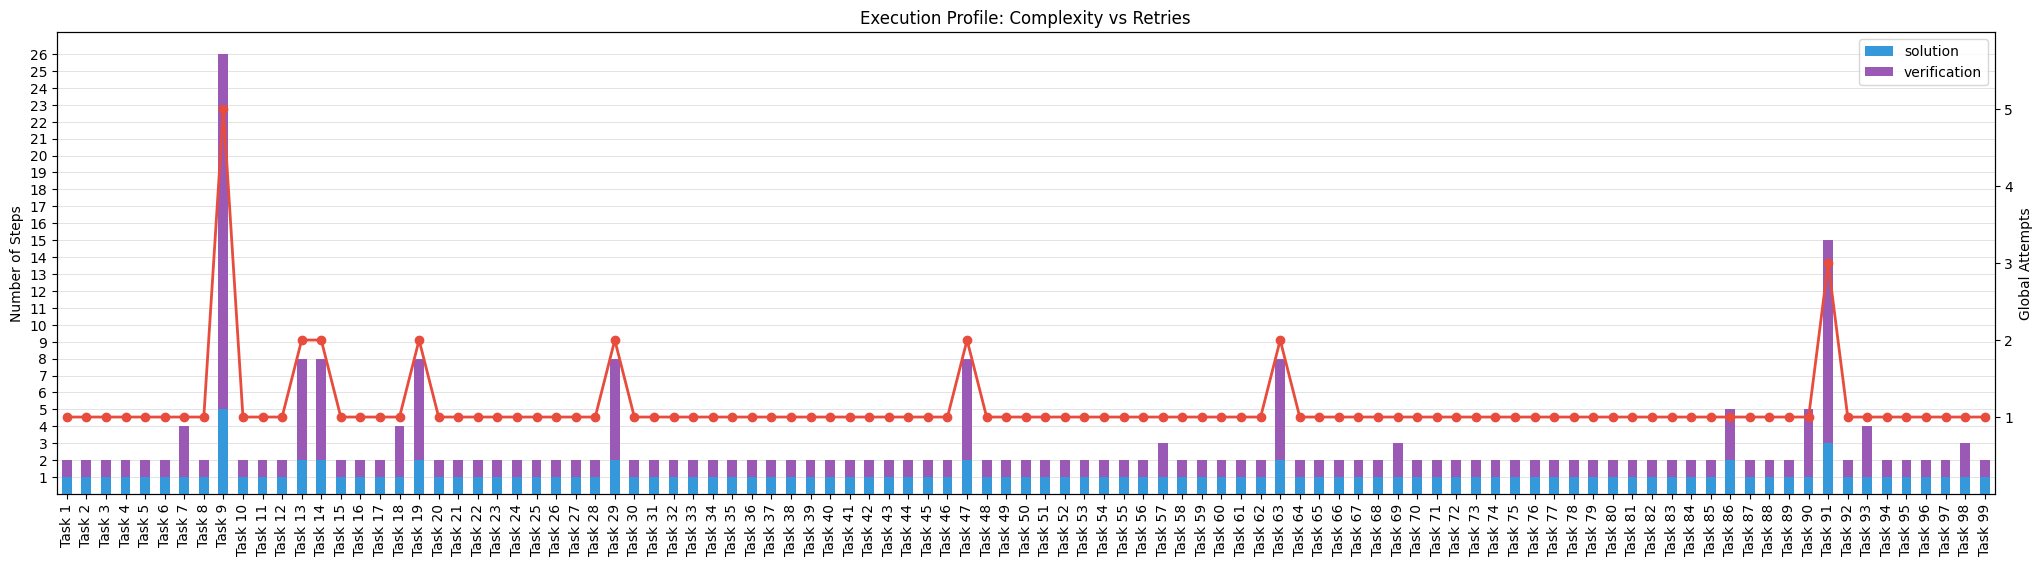

In [95]:
import matplotlib.pyplot as plt
import pandas as pd

# data = trace
df = pd.DataFrame(trace)

# Combined chart
fig, ax1 = plt.subplots(figsize=(25, 6))

# Bars for complexity
df[['solution', 'verification']].plot(
    kind='bar',
    stacked=True,
    ax=ax1,
    color=['#3498db', '#9b59b6'],
    zorder=10
)
mx = (df['solution'] + df['verification']).max()
ax1.set_ylabel('Number of Steps')
ax1.set_yticks(range(1, mx+1))
ax1.grid(True, axis='y', zorder=0)

# Line for global attempts
ax2 = ax1.twinx()
ax2.plot(
    df.index,
    df['attempts'],
    color='#e74c3c',
    marker='o',
    linewidth=2,
    label='Global Attempts',
    zorder=10
)
ax2.set_ylabel('Global Attempts')

mx2 = df['attempts'].max() + 1
ax2.set_yticks(range(1, mx2))
ax2.set_ylim(0, mx2)
# ax2.grid(True, axis='y', zorder=0)
ax2.set_xticklabels([f"Task {i+1}" for i in range(df.shape[0])])

plt.title('Execution Profile: Complexity vs Retries')
plt.show()